# Ebro Delta Coastal Erosion Analysis — 2016 to 2024

Tracking coastline change on the Ebro Delta (Tarragona, Spain) using
  Sentinel-2 imagery
  and Copernicus Marine environmental variables.

In [10]:
import pystac_client                                      
import planetary_computer                                                                                                                                     
import numpy as np                                                                                                                                            
                                                                                                                                                                
  # Connect to Planetary Computer                                                                                                                               
catalog = pystac_client.Client.open(                                                                                                                          
      "https://planetarycomputer.microsoft.com/api/stac/v1",                                                                                                    
      modifier=planetary_computer.sign_inplace,
  )

In [15]:
YEARS = [2016, 2018, 2020, 2022, 2024]                    
BBOX  = [0.55, 40.55, 1.05, 40.90]                                                                                                                            
CLOUD_THRESHOLD = 10                                                                                                                                          
                                                                                                                                                                
best_items = {}   # {year: pystac Item}                                                                                                                       
                                                            
for year in YEARS:                                                                                                                                            
      search = catalog.search(                              
          collections=["sentinel-2-l2a"],                                                                                                                       
          bbox=BBOX,
          datetime=f"{year}-03-01/{year}-06-30",                                                                                                                
          query={"eo:cloud_cover": {"lt": CLOUD_THRESHOLD}},                                                                                                    
      )
      items = list(search.items())                                                                                                                              
      if not items:                                                                                                                                             
          print(f"{year}: NO SCENES FOUND — try relaxing cloud threshold")
          continue                                                                                                                                              
      best = sorted(items, key=lambda i: i.properties["eo:cloud_cover"])[0]
      best_items[year] = best                                                                                                                                   
      print(f"{year}: {best.id}  cloud={best.properties['eo:cloud_cover']:.1f}%")                                                                               
                                                                                                                                                                
print(f"\nFound scenes for {len(best_items)}/5 years")

2016: S2A_MSIL2A_20160424T105652_R094_T31TBF_20210211T060340  cloud=0.0%
2018: S2B_MSIL2A_20180307T105019_R051_T31TCE_20201013T074835  cloud=0.0%
2020: S2A_MSIL2A_20200626T104031_R008_T30TYK_20200824T041918  cloud=0.0%
2022: S2A_MSIL2A_20220527T103631_R008_T30TYK_20220528T120630  cloud=0.0%
2024: S2B_MSIL2A_20240312T103729_R008_T30TYK_20240312T150524  cloud=0.0%

Found scenes for 5/5 years


In [19]:
from odc.stac import stac_load

rgb_scenes = {}   # {year: xr.DataArray with dims (band, y, x)}

for year, item in best_items.items():
      print(f"Loading {year}...", end=" ")
      ds = stac_load(
          [item],
          bands=["B04", "B03", "B02", "B08"],
          bbox=BBOX,
          resolution=60,
          crs="EPSG:32631",          # UTM zone 31N — meters, covers Ebro Delta
          chunks={"x": 1024, "y": 1024},
      )
      scene = ds.isel(time=0)
      rgb = scene[["B04", "B03", "B02"]].to_array(dim="band")
      rgb_scaled = (rgb.clip(0, 3000) / 3000).compute()
      rgb_scenes[year] = rgb_scaled
      print(f"done — shape {rgb_scaled.shape}")

print(f"\nLoaded {len(rgb_scenes)} scenes")

Loading 2016... 

/srv/conda/envs/notebook/lib/python3.13/site-packages/rasterio/warp.py:385: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


done — shape (3, 667, 721)
Loading 2018... done — shape (3, 667, 721)
Loading 2020... done — shape (3, 667, 721)
Loading 2022... done — shape (3, 667, 721)
Loading 2024... done — shape (3, 667, 721)

Loaded 5 scenes


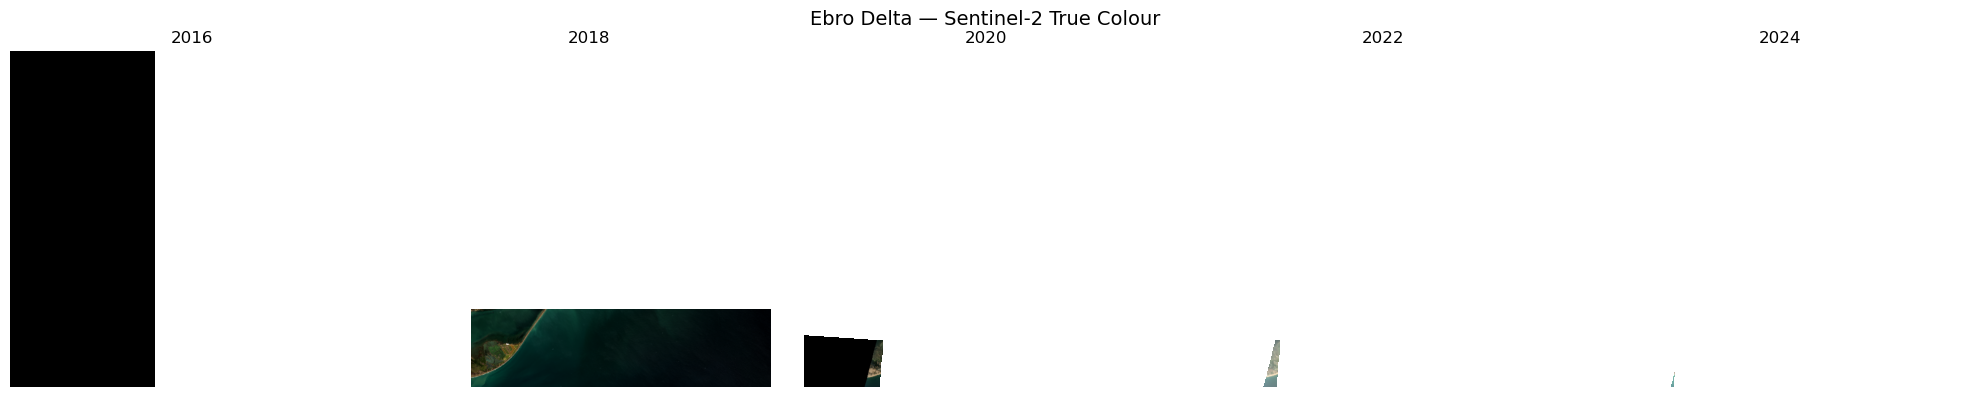

In [22]:
  import matplotlib.pyplot as plt                                                                                                                               
  import numpy as np
                                                                                                                                                                
  fig, axes = plt.subplots(1, 5, figsize=(20, 4))                                                                                                               
  
  for ax, year in zip(axes, sorted(rgb_scenes.keys())):                                                                                                         
      rgb = rgb_scenes[year]
      # transpose from (band, y, x) → (y, x, band) for imshow                                                                                                   
      img = np.transpose(rgb.values, (1, 2, 0))                                                                                                                 
      ax.imshow(img)                                                                                                                                            
      ax.set_title(str(year))                                                                                                                                   
      ax.axis("off")                                                                                                                                            
                                                                                                                                                                
  plt.suptitle("Ebro Delta — Sentinel-2 True Colour", fontsize=14)                                                                                              
  plt.tight_layout()                                                                                                                                            
  plt.show()

In [23]:
  for year in sorted(rgb_scenes.keys()):                                                                                                                        
      rgb = rgb_scenes[year]                                                                                                                                    
      print(f"{year}: min={float(rgb.min()):.3f}  max={float(rgb.max()):.3f}  "                                                                                 
            f"nan_count={int(rgb.isnull().sum())}  shape={rgb.shape}") 

2016: min=0.000  max=0.000  nan_count=866433  shape=(3, 667, 721)
2018: min=0.000  max=1.000  nan_count=1162005  shape=(3, 667, 721)
2020: min=0.000  max=0.822  nan_count=1396560  shape=(3, 667, 721)
2022: min=0.419  max=1.000  nan_count=1436718  shape=(3, 667, 721)
2024: min=0.000  max=0.979  nan_count=1441912  shape=(3, 667, 721)
